Importy

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import joblib
import glob
import itertools
import copy
import os

Wspólne klasy i funkcje sieci

In [2]:
class SubNetwork(nn.Module):
    def __init__(self, input_dim, output_dim=1):
        super(SubNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, output_dim)
        )
    def forward(self, x): return self.net(x)

def train_greybox_model(model, dataloader, epochs=2000, patience=80, min_delta=1e-6):
    optimizer = optim.Adam(model.parameters(), lr=5e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.97)
    criterion = nn.L1Loss() 
    
    # --- Zmienne dla Early Stopping ---
    best_loss = float('inf') # Ustawiamy początkowy "najlepszy" błąd na nieskończoność
    patience_counter = 0     # Licznik epok bez poprawy
    best_model_weights = copy.deepcopy(model.state_dict()) # Tu będziemy trzymać kopię najlepszych wag
    
    model.train()
    print(f"Rozpoczynam trening (Maksymalnie {epochs} epok, Cierpliwość: {patience})...")
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        # Przejście przez wszystkie paczki danych
        for u_seq, y_true_seq in dataloader:
            x_init = torch.zeros(u_seq.size(0), model.num_states)
            optimizer.zero_grad()
            y_pred_seq = model(u_seq, x_init)
            loss = criterion(y_pred_seq.view_as(y_true_seq), y_true_seq)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        scheduler.step()
        avg_loss = epoch_loss / len(dataloader)
        
        # Wypisywanie postępu
        if (epoch + 1) % 10 == 0:
            print(f"Epoka {epoch+1}/{epochs} | Strata MSE: {avg_loss:.6f}")
            
        # --- LOGIKA EARLY STOPPING ---
        # Sprawdzamy, czy obecna strata jest zauważalnie lepsza od najlepszej dotychczasowej
        if best_loss - avg_loss > min_delta:
            best_loss = avg_loss               # Zapisujemy nowy rekord
            patience_counter = 0               # Zerujemy licznik cierpliwości
            best_model_weights = copy.deepcopy(model.state_dict()) # Kopiujemy i zapisujemy te najlepsze wagi!
        else:
            patience_counter += 1              # Brak poprawy, zwiększamy licznik
            
        # Jeśli straciliśmy cierpliwość (licznik przekroczył limit)
        if patience_counter >= patience:
            print(f"\n[!] EARLY STOPPING: Przerwano trening w epoce {epoch+1}!")
            print(f"Brak poprawy o minimum {min_delta} od {patience} epok.")
            break # Wychodzimy z głównej pętli treningowej
            
    # Po zakończeniu pętli (niezależnie czy doszła do 2000, czy ucięło ją wcześnie)
    # wgrywamy z powrotem NAJLEPSZE wagi, żeby nie zwracać modelu z ostatniej, gorszej epoki.
    model.load_state_dict(best_model_weights)
    print(f"Trening zakończony. Załadowano najlepsze wagi ze stratą MSE: {best_loss:.6f}\n")
    
    return model

def create_sequences(inputs, targets, seq_len=600):
    xs, ys = [], []
    for i in range(0, len(inputs) - seq_len + 1, seq_len):
        xs.append(inputs[i : i + seq_len])
        ys.append(targets[i : i + seq_len])
    return np.array(xs), np.array(ys)


# ULEPSZONA FUNKCJA WALIDACJI Z FILTREM REZIDUUM I "STREFĄ CISZY" (Burn-in)
# ==========================================
def validate_and_plot(model, scaler_u, scaler_y, input_cols, target_cols, file_path, title_prefix, alpha=0.05, threshold=None, burn_in=0):
    # Wczytanie i przygotowanie danych
    df_test = pd.read_csv(file_path)
    
    # =========================================================
    # NAPRAWA: OBLICZANIE CECH W LOCIE DLA DANYCH TESTOWYCH
    # =========================================================
    # Jeśli nasze wejścia wymagają cech WAF, wyliczamy je z surowych kolumn:
    if 'waf_x1' in input_cols and 'waf_x1' not in df_test.columns:
        epsilon = 1e-6
        df_test['waf_x1'] = np.log(df_test['engine_speed'] + epsilon) * df_test['air_mass_flow']
        df_test['waf_x2'] = df_test['air_mass_flow']
        df_test['waf_x3'] = np.log(df_test['throttle_position'] + epsilon)
    # =========================================================

    X_test_tensor = torch.tensor(scaler_u.transform(df_test[input_cols].values), dtype=torch.float32).unsqueeze(0)
    Y_test_tensor = torch.tensor(scaler_y.transform(df_test[target_cols].values), dtype=torch.float32).unsqueeze(0)
    
    # Przewidywanie modelu
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor, torch.zeros(1, model.num_states))
        
    y_pred_real = scaler_y.inverse_transform(y_pred[0].cpu().numpy().reshape(-1, 1))
    y_true_real = scaler_y.inverse_transform(Y_test_tensor[0].cpu().numpy().reshape(-1, 1))
    czas = np.arange(len(y_true_real)) * 0.05
    
    # ---------------------------------------------------------
    # OBLICZANIE I FILTROWANIE REZIDUUM (BŁĘDU BEZWZGLĘDNEGO)
    # ---------------------------------------------------------
    e_raw = np.abs(y_true_real - y_pred_real) # Surowy błąd
    e_filtered = np.zeros_like(e_raw)         # Pusta tablica na przefiltrowany błąd
    e_filtered[0] = e_raw[0]                  # Stan początkowy
    
    # Pętla filtru EMA (Exponential Moving Average)
    for i in range(1, len(e_raw)):
        e_filtered[i] = alpha * e_raw[i] + (1 - alpha) * e_filtered[i-1]
        
    # --- NAPRAWA BŁĘDU STANU POCZĄTKOWEGO (Burn-in period) ---
    if burn_in > 0:
        e_raw[:burn_in] = 0.0
        e_filtered[:burn_in] = 0.0
    
    # ---------------------------------------------------------
    # RYSOWANIE WYKRESÓW
    # ---------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Górny wykres: Fizyka
    ax1.plot(czas, y_true_real, label='Prawda (Czujnik)', color='black', alpha=0.7)
    ax1.plot(czas, y_pred_real, label='Symulacja (AI)', color='red', linestyle='--', alpha=0.9)
    ax1.set_title(f'{title_prefix} | Plik: {file_path.split("/")[-1]}', fontsize=12)
    ax1.set_ylabel('Wartość fizyczna')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.7)
    
    # Dolny wykres: Diagnostyka
    ax2.plot(czas, e_raw, label='Surowe Reziduum (Szum)', color='gray', alpha=0.4)
    ax2.plot(czas, e_filtered, label=f'Przefiltrowane Reziduum (alpha={alpha})', color='darkred', linewidth=2)
    
    if threshold is not None:
        ax2.axhline(threshold, color='orange', linestyle='--', linewidth=2, label=f'Próg Detekcji ({threshold})')
        
    ax2.set_title('Sygnał Diagnostyczny (Reziduum)', fontsize=12)
    ax2.set_xlabel('Czas [s]')
    ax2.set_ylabel('Błąd predykcji')
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Statystyki z pominięciem rozgrzewki
    print(f"Średni błąd bezwzględny (MAE po rozgrzewce): {np.mean(e_raw[burn_in:]):.4f}")
    print(f"Maksymalny błąd przefiltrowany (po rozgrzewce): {np.max(e_filtered[burn_in:]):.4f}")

MSO_10 - Intercooler

In [3]:
class GreyBoxSystem_WAF(nn.Module):
    def __init__(self, T_sample=0.05, num_states=1):
        super(GreyBoxSystem_WAF, self).__init__()
        # ZMIANA: 1 stan ukryty, 3 wejścia (bo mamy 3 cechy z artykułu)
        self.T, self.num_states, self.num_inputs = T_sample, num_states, 3 
        total_feat = self.num_states + self.num_inputs
        
        # ZMIANA: g_func musi zwracać tyle wartości, ile jest stanów (czyli 1)
        self.g_func = SubNetwork(total_feat, self.num_states) 
        self.h_func = SubNetwork(total_feat, 1)

    def forward(self, u_seq, x_init):
        x_t, preds = x_init, []
        for t in range(u_seq.size(1)):
            inputs = torch.cat((x_t, u_seq[:, t, :]), dim=1)
            preds.append(self.h_func(inputs))
            x_t = x_t + self.T * self.g_func(inputs)
        return torch.stack(preds, dim=1)

DATA_DIR = r"C:\Users\anton\OneDrive\Desktop\data"

HEALTHY_FILES = glob.glob(os.path.join(DATA_DIR, "*_NF*.csv"))
FAULTY_FILES_PIM = glob.glob(os.path.join(DATA_DIR, "*_f_pim*.csv"))
FAULTY_FILES_PIC = glob.glob(os.path.join(DATA_DIR, "*_f_pic*.csv"))
FAULTY_FILES_WAF = glob.glob(os.path.join(DATA_DIR, "*_f_waf*.csv"))
FAULTY_FILES_IML = glob.glob(os.path.join(DATA_DIR, "*_f_iml*.csv"))

healthy_dfs = [pd.read_csv(f) for f in HEALTHY_FILES]
faulty_dfs_pic = [pd.read_csv(f) for f in FAULTY_FILES_PIC]
faulty_dfs_pim = [pd.read_csv(f) for f in FAULTY_FILES_PIM]


df_train_nf = pd.concat(healthy_dfs + faulty_dfs_pic + faulty_dfs_pim, ignore_index=True)

# ==========================================
# 2. DROGA A: INŻYNIERIA CECH (Wzór z artykułu)
# ==========================================
epsilon = 1e-6 # Zabezpieczenie przed log(0)
df_train_nf['waf_x1'] = np.log(df_train_nf['engine_speed'] + epsilon) * df_train_nf['air_mass_flow']
df_train_nf['waf_x2'] = df_train_nf['air_mass_flow']
df_train_nf['waf_x3'] = np.log(df_train_nf['throttle_position'] + epsilon)

# Definiujemy wejścia na nowo:
u_cols = ['waf_x1', 'waf_x2', 'waf_x3'] 
y_cols = ['injected_fuel_mass']

# ==========================================
# 3. SKALOWANIE I TWORZENIE SEKWENCJI
# ==========================================
scaler_uwaf = MinMaxScaler()
scaler_ywaf = MinMaxScaler()

uwaf_norm = scaler_uwaf.fit_transform(df_train_nf[u_cols].values)
ywaf_norm = scaler_ywaf.fit_transform(df_train_nf[y_cols].values)

X_seq_waf, Y_seq_waf = create_sequences(uwaf_norm, ywaf_norm)
loader_waf = DataLoader(TensorDataset(torch.tensor(X_seq_waf, dtype=torch.float32), 
                                      torch.tensor(Y_seq_waf, dtype=torch.float32)), 
                        batch_size=16, shuffle=True)

# --- TRENOWANIE ---
# Odkomentuj poniższe linie, gdy chcesz wytrenować model na nowo
#model_waf = GreyBoxSystem_WAF()
#model_waf = train_greybox_model(model_waf, loader_waf, epochs=2000)

# ZMIANA: Zapisujemy z nazwami "waf", żeby nie nadpisać MSO_10!
#torch.save(model_waf.state_dict(), 'szara_skrzynka_waf_wagi.pth')
#joblib.dump(scaler_uwaf, 'scaler_u_waf.pkl')
#joblib.dump(scaler_ywaf, 'scaler_y_waf.pkl')

print("Komórka hybrydowa WAF gotowa do treningu!")

Komórka hybrydowa WAF gotowa do treningu!


Model MSO 10 (2 stany) i skalery zostały pomyślnie wczytane z dysku!


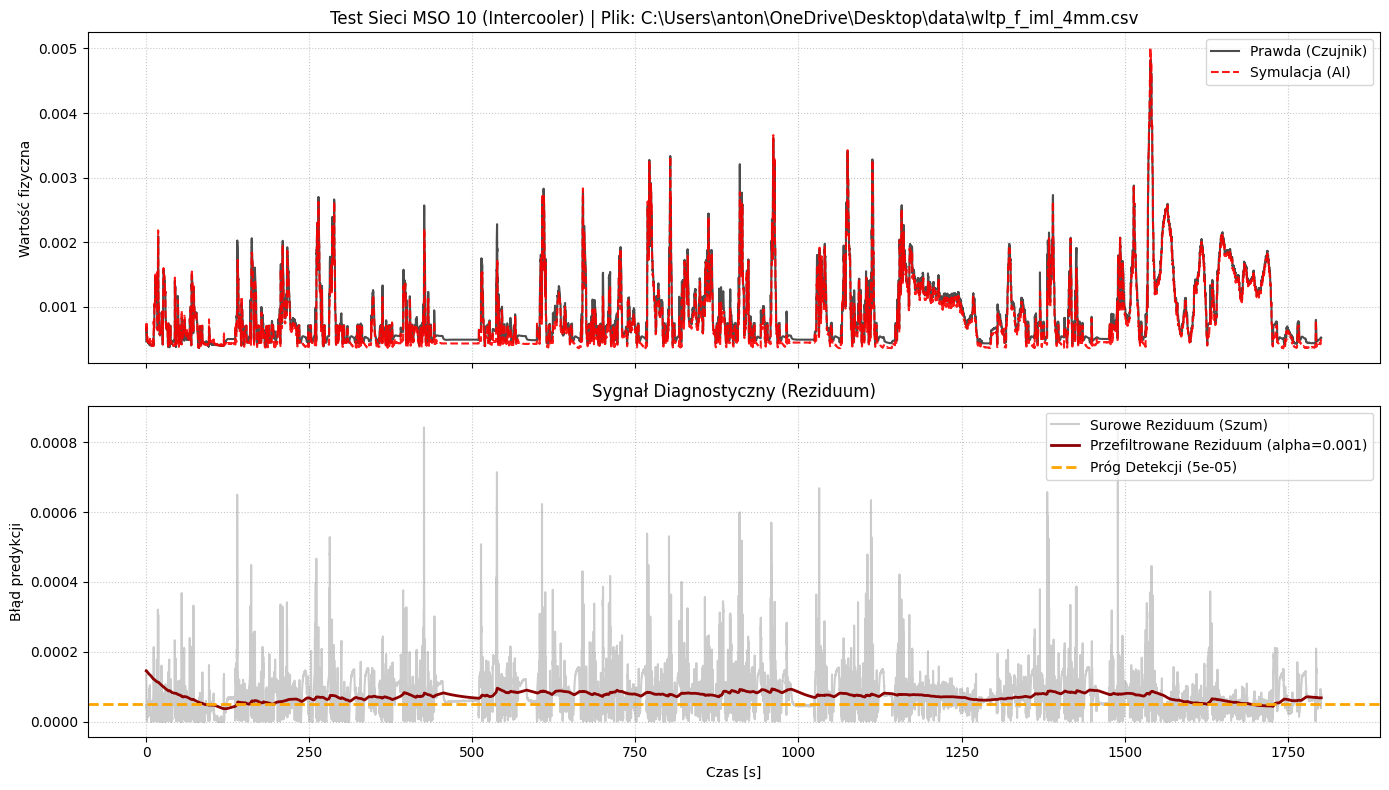

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0001
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0001


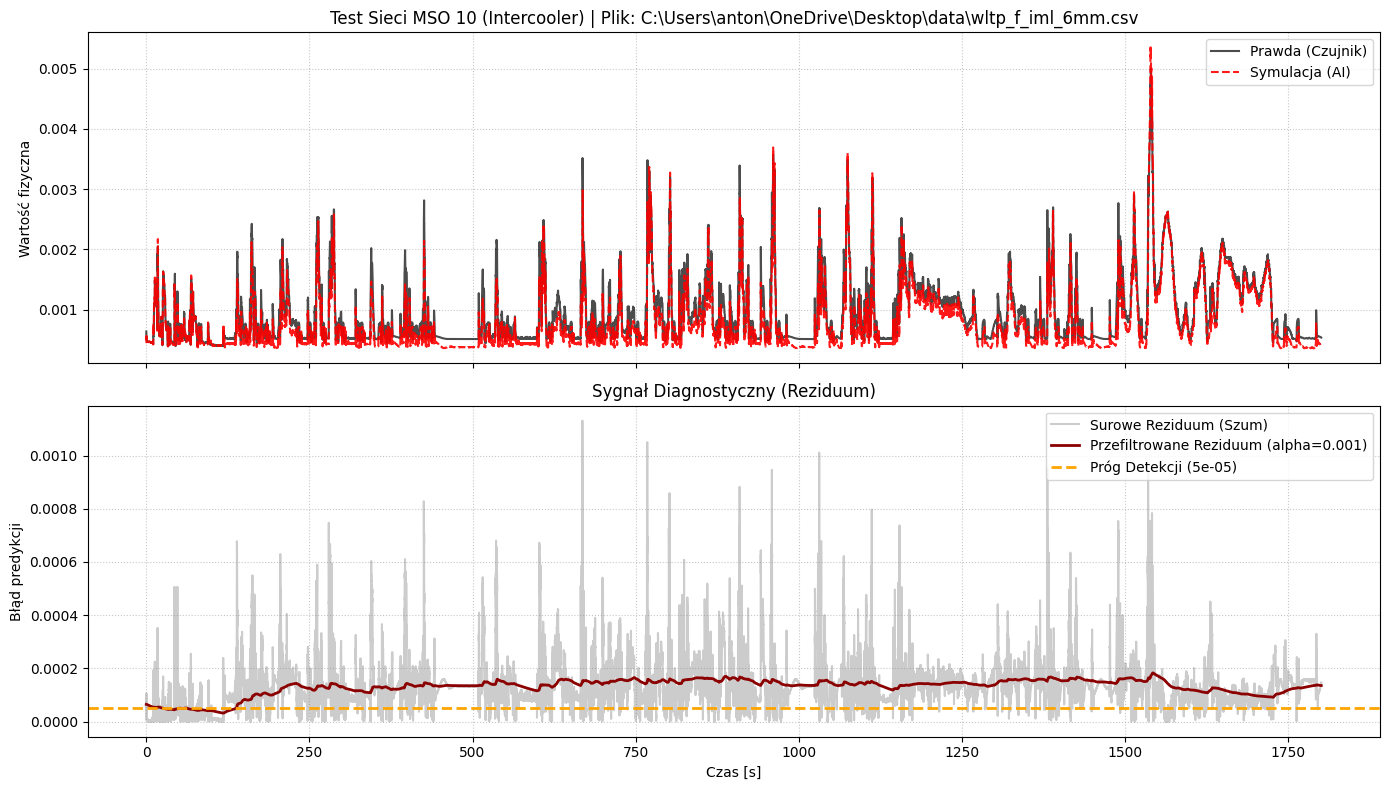

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0001
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0002


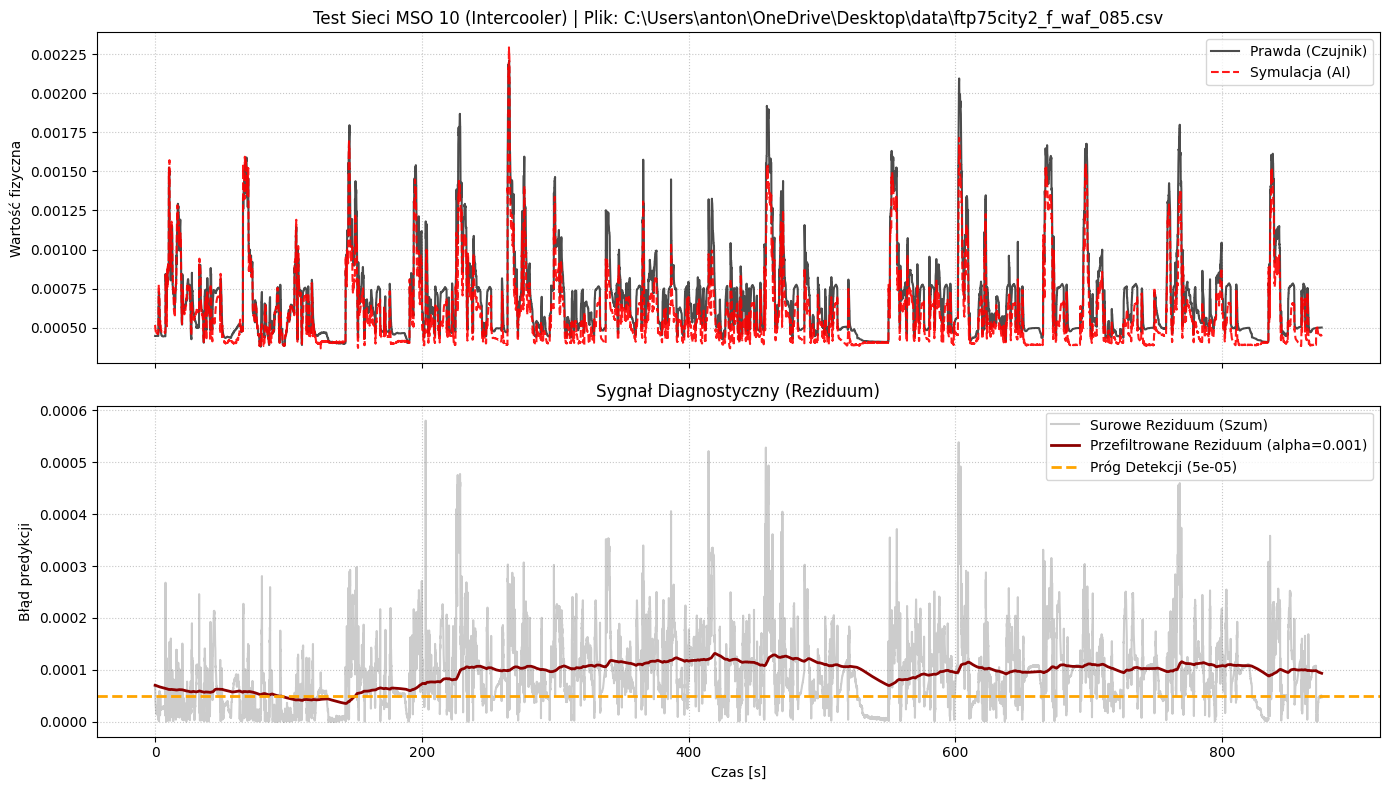

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0001
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0001


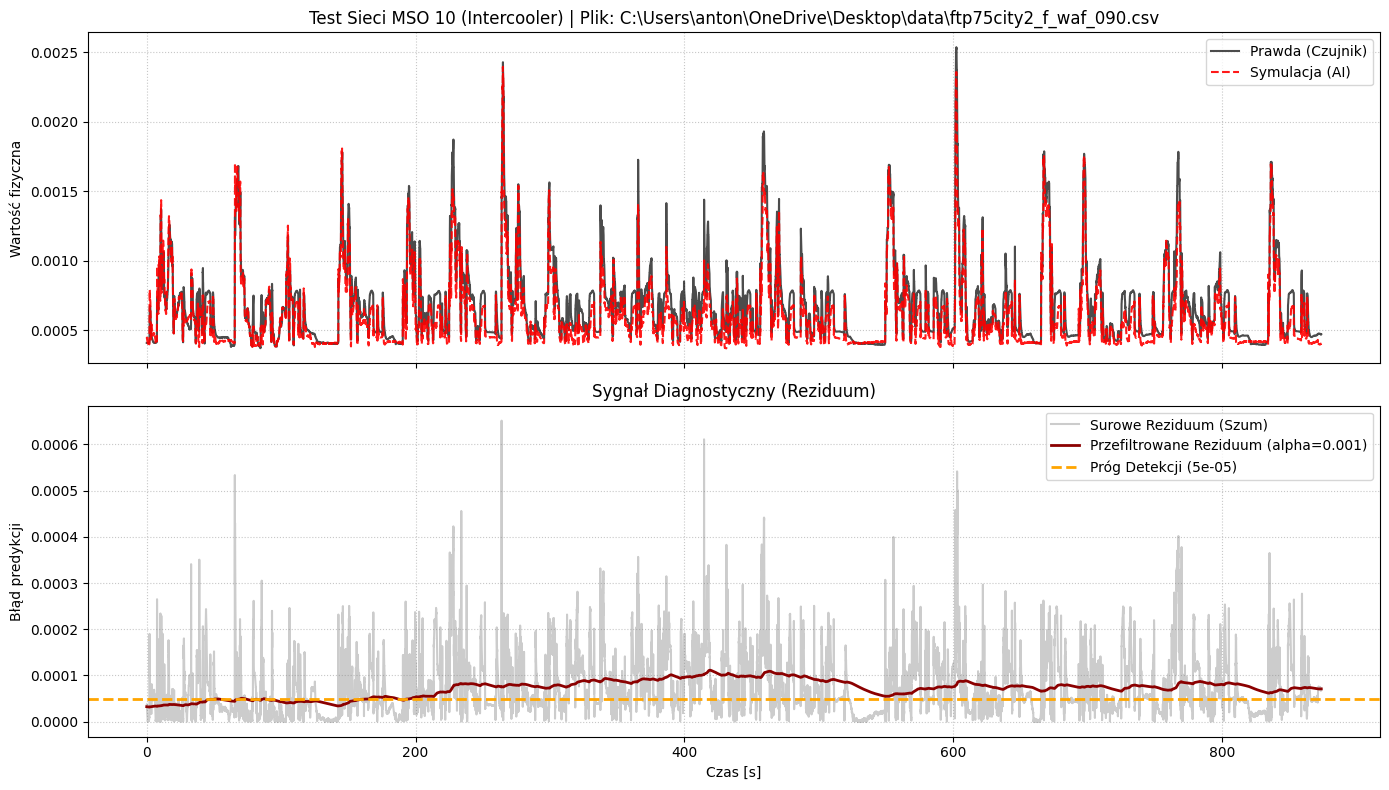

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0001
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0001


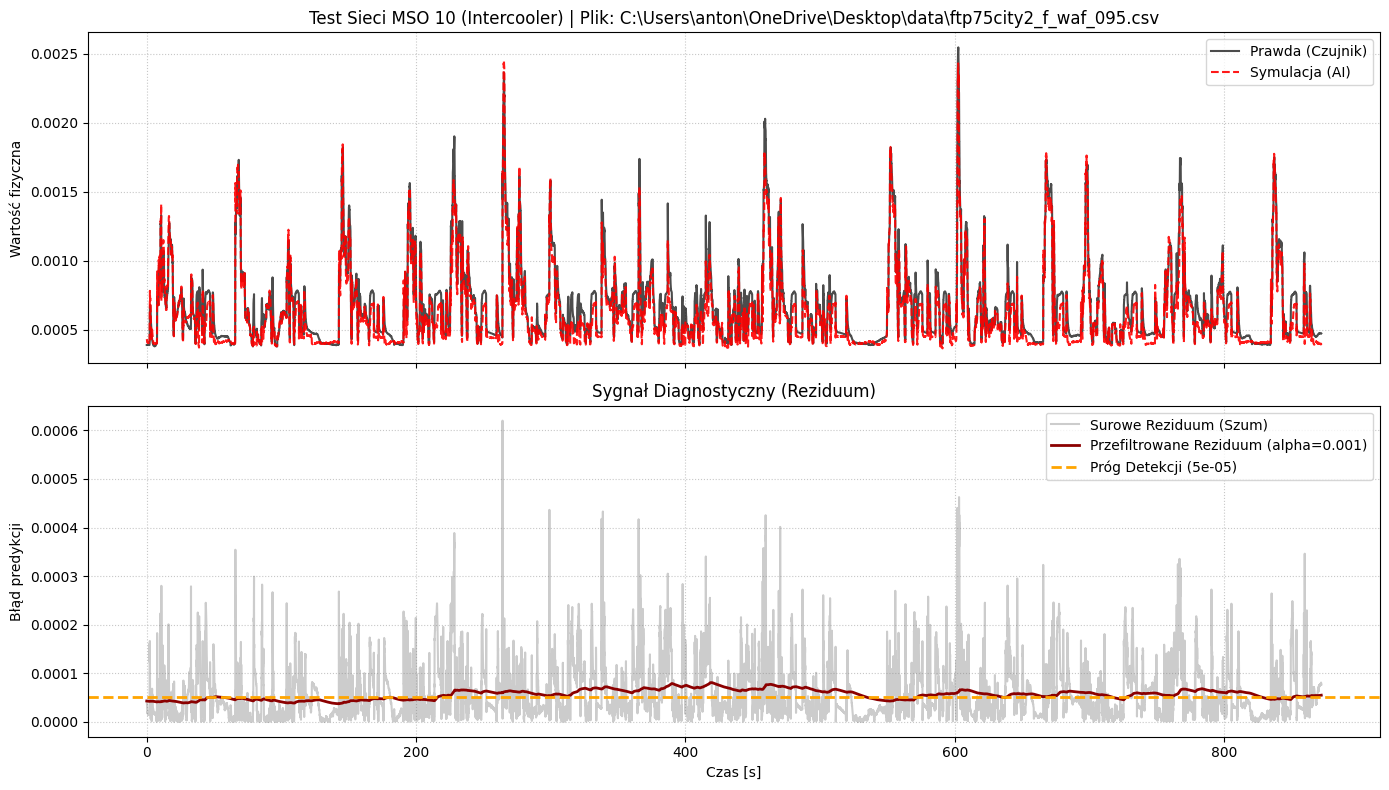

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0001
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0001


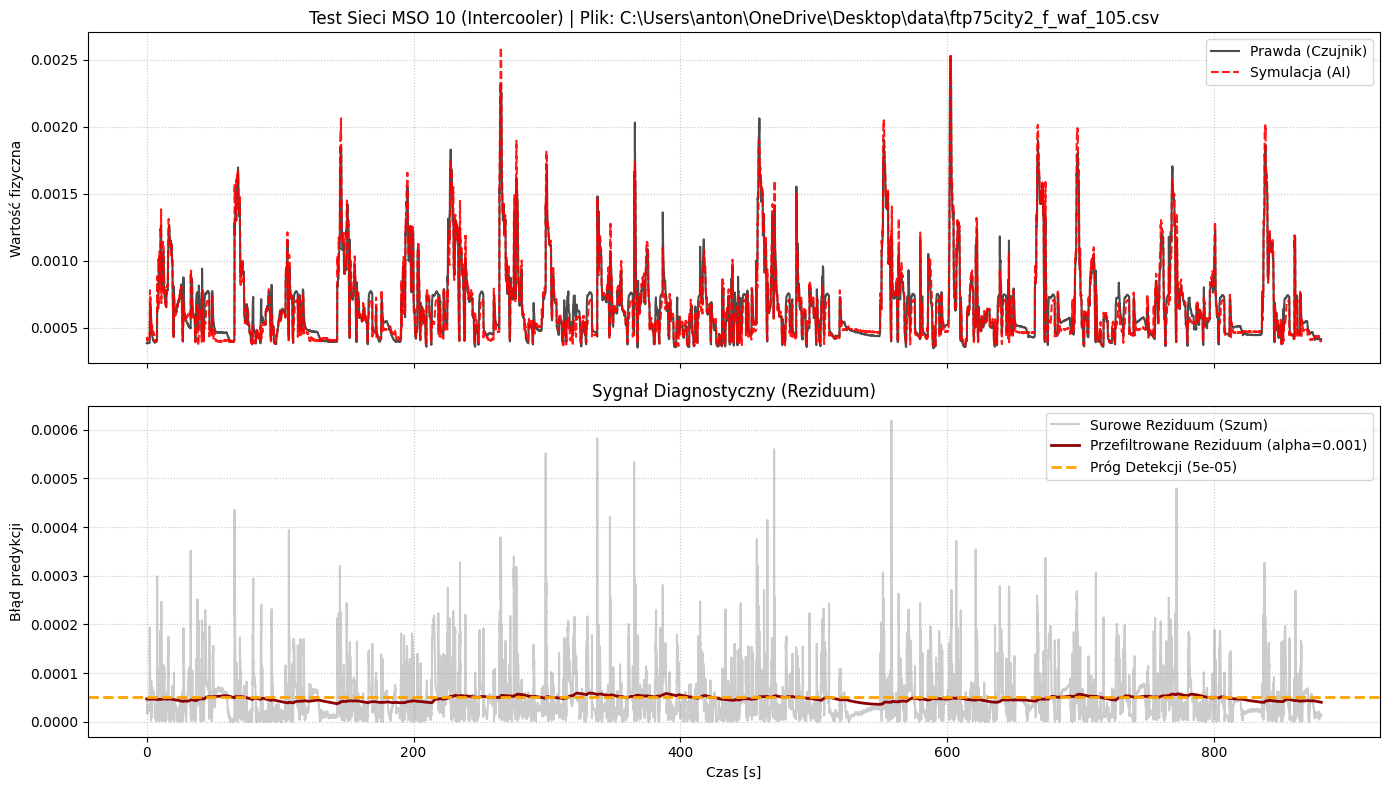

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0000
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0001


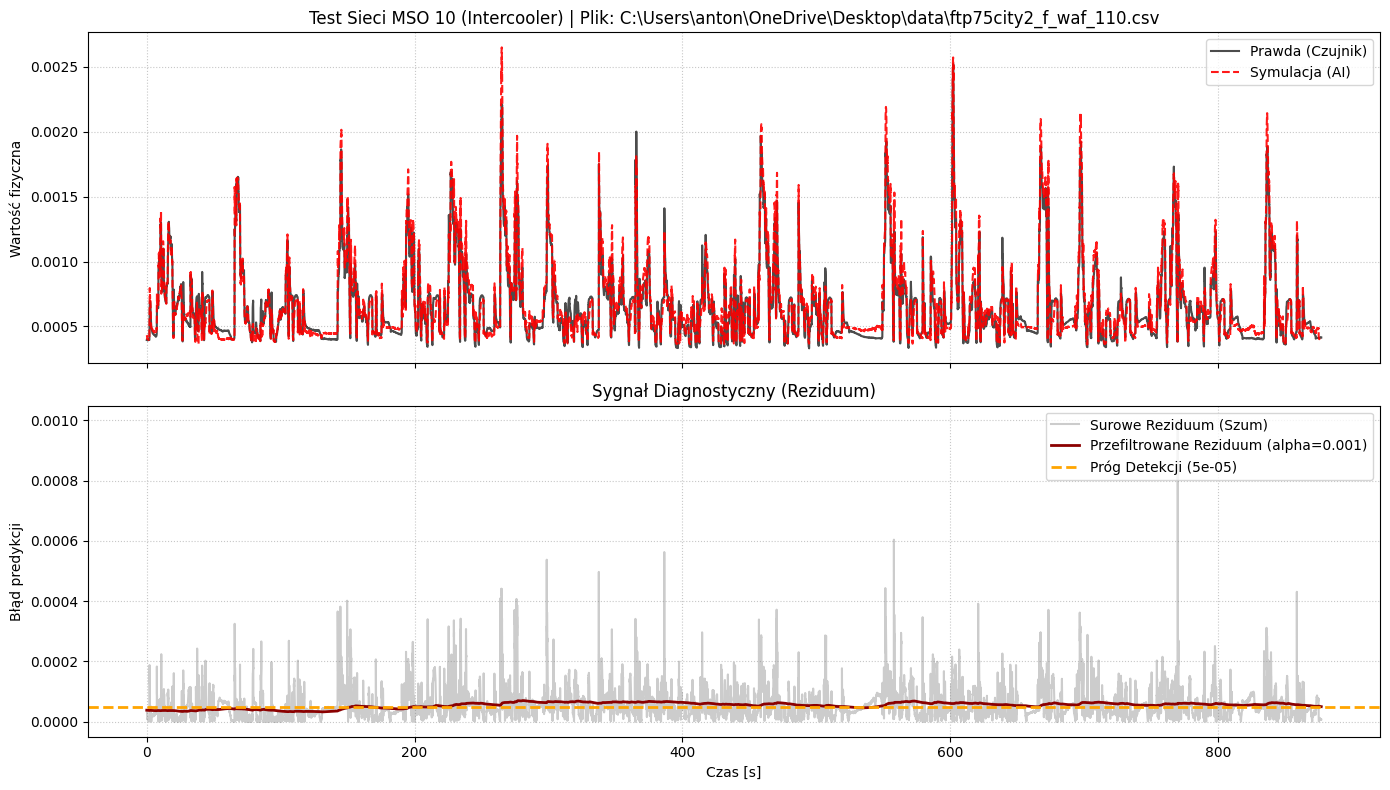

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0001
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0001


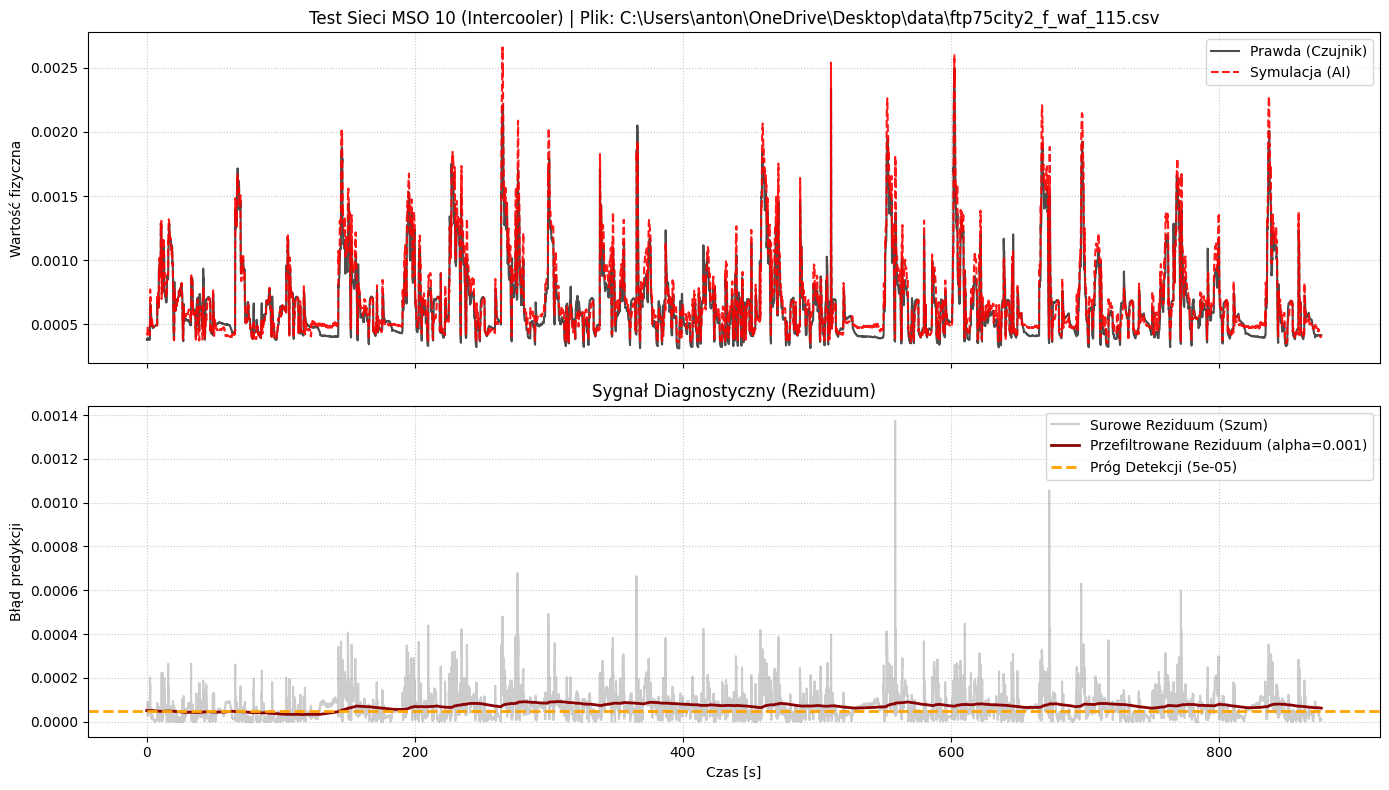

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0001
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0001


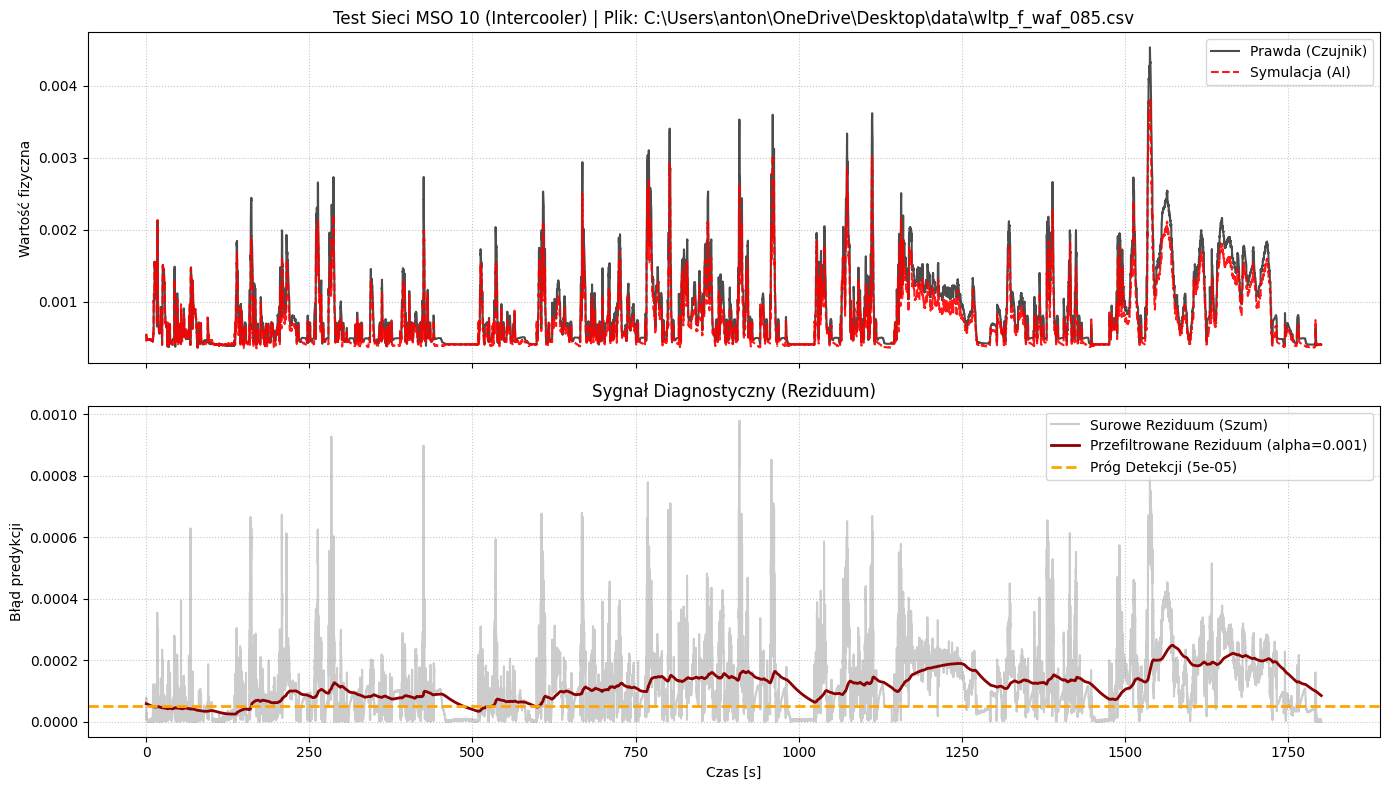

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0001
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0002


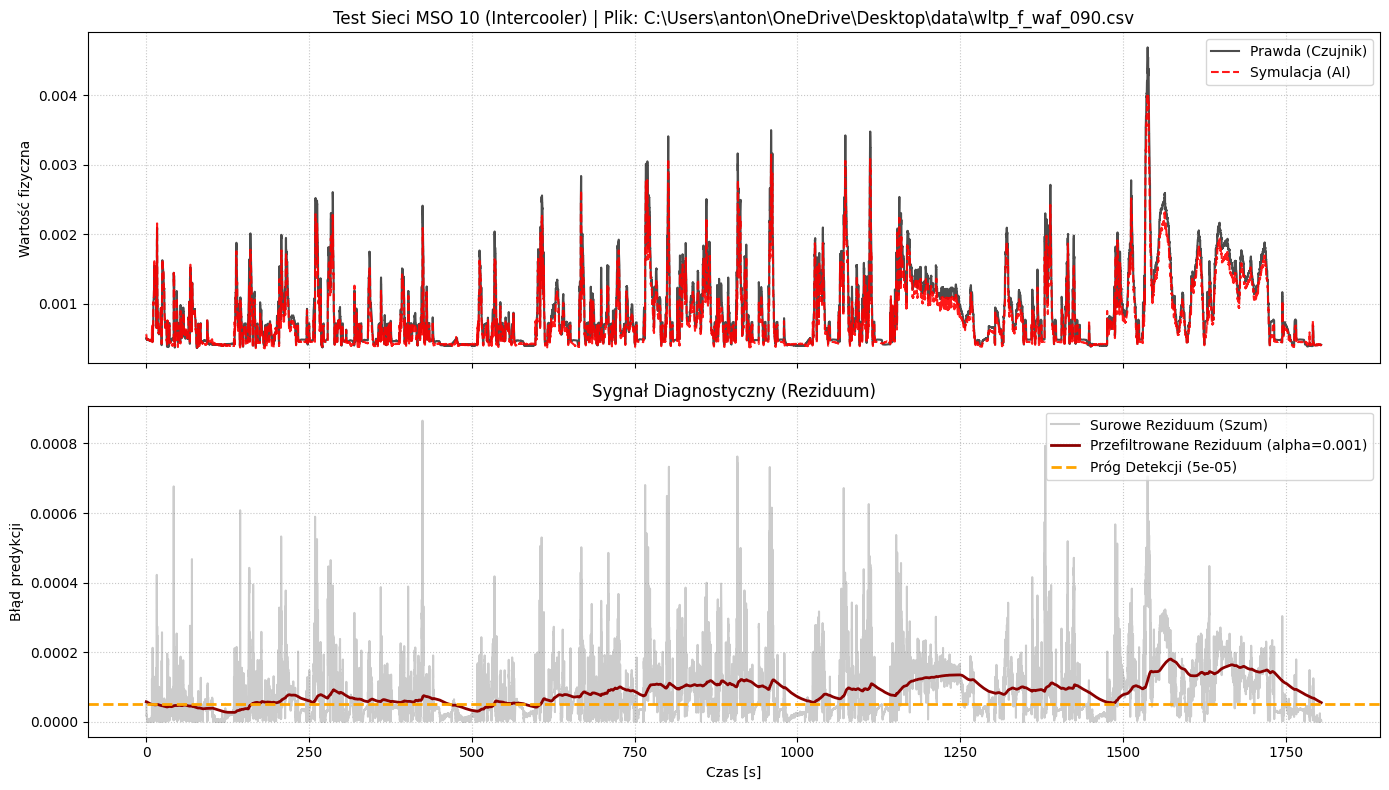

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0001
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0002


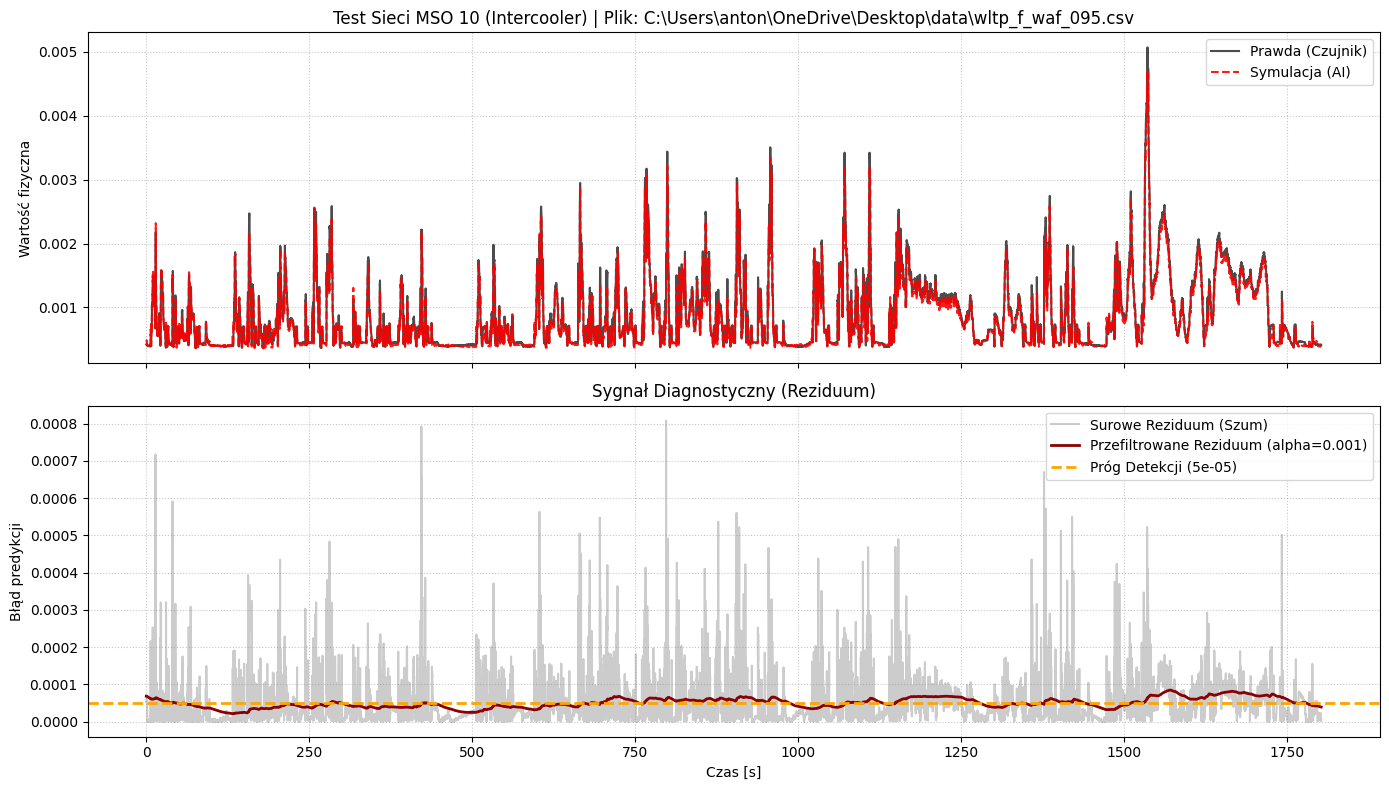

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0000
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0001


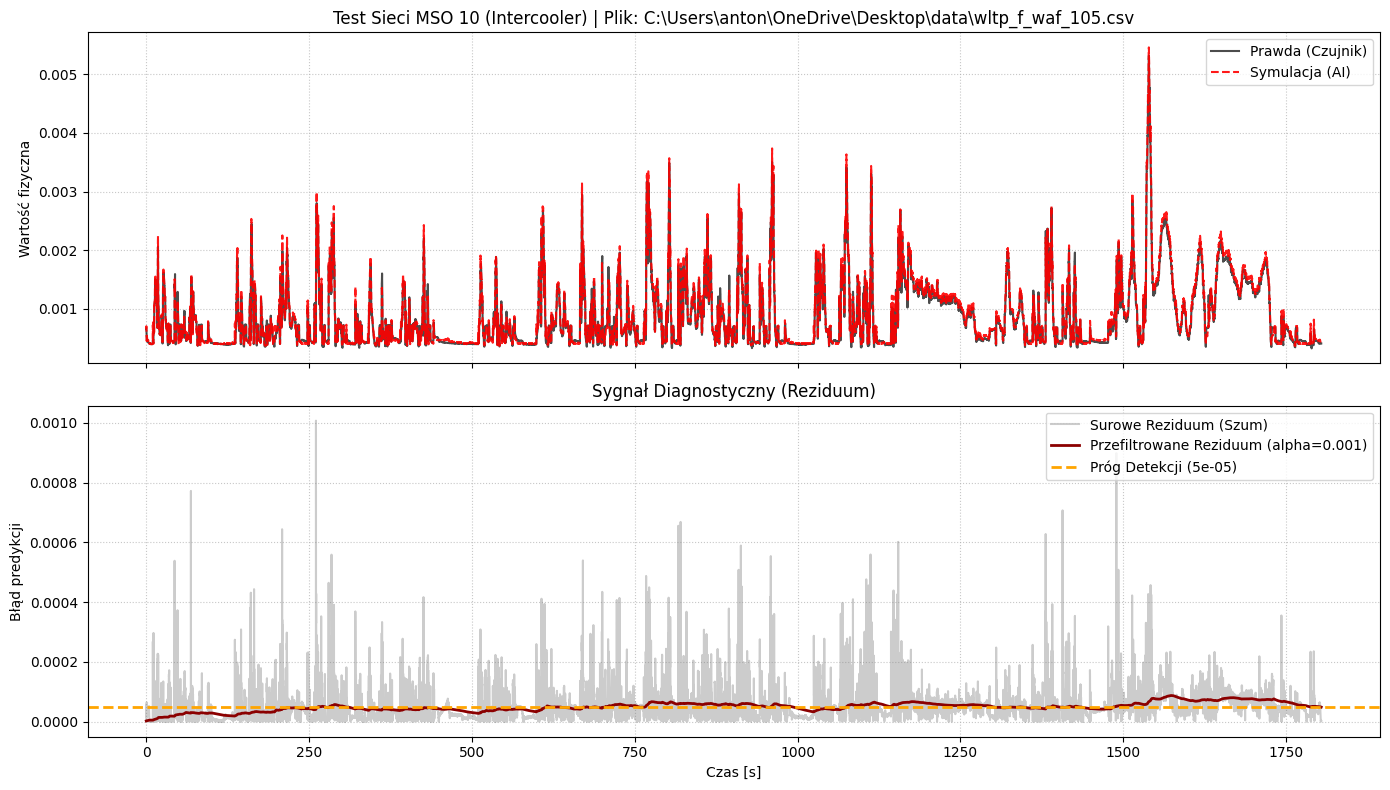

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0001
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0001


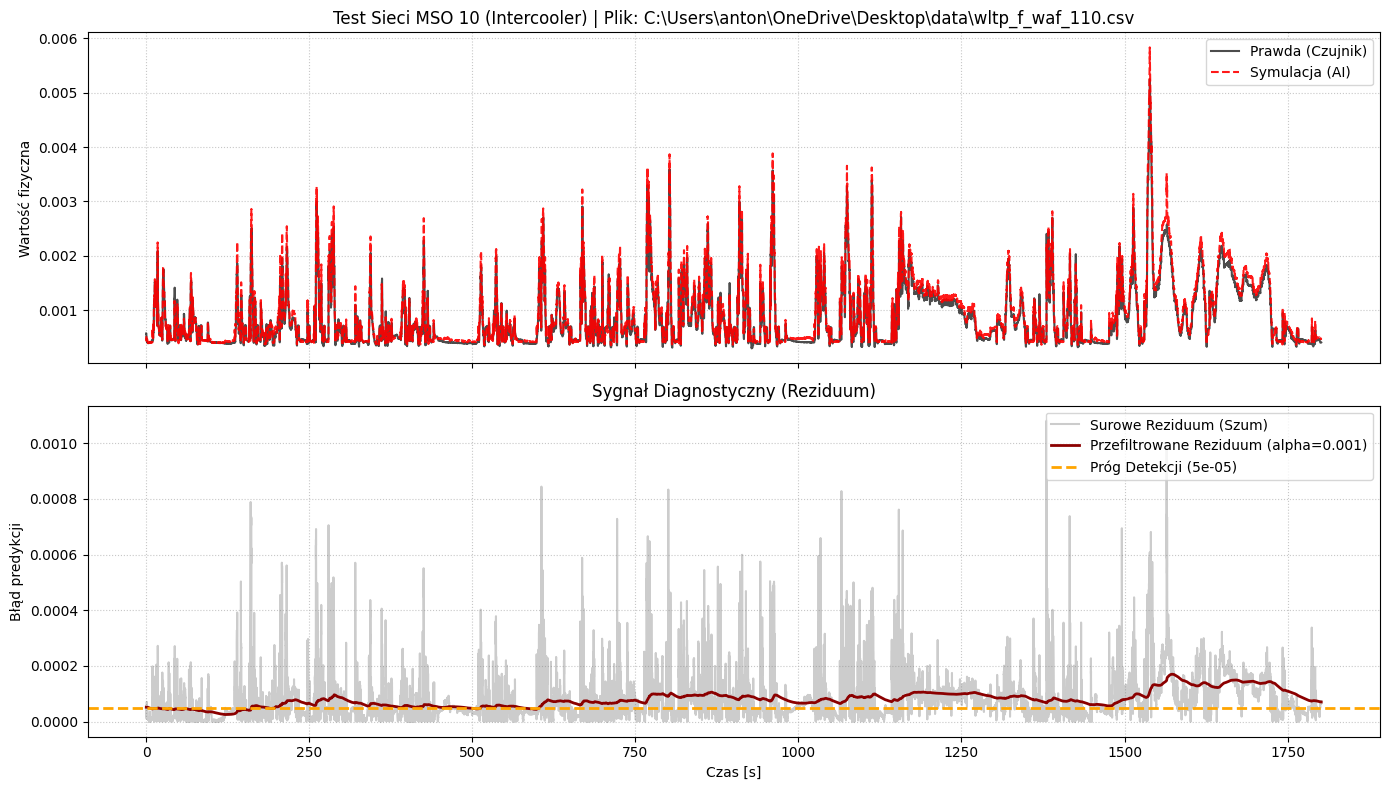

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0001
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0002


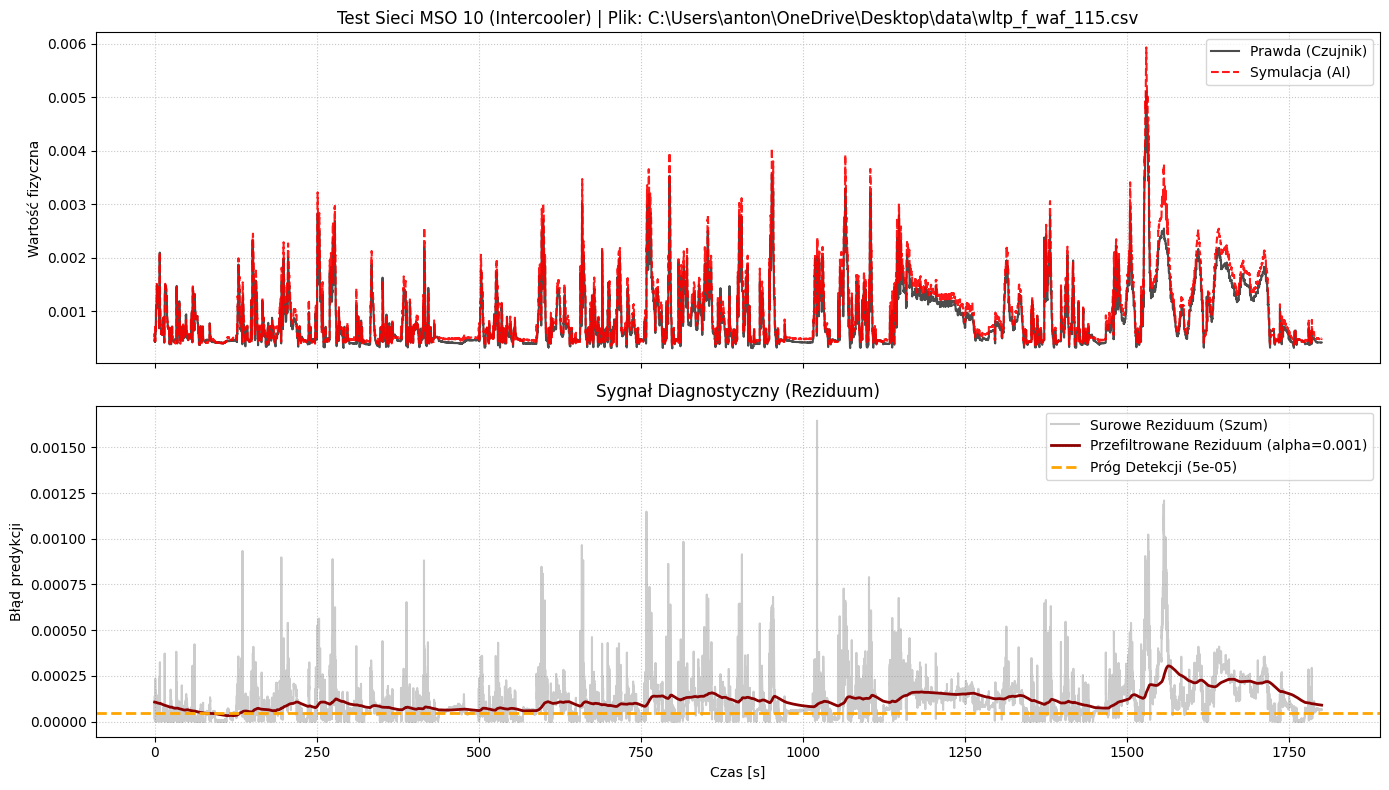

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0001
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0003


In [6]:
model10 = GreyBoxSystem_WAF(T_sample=0.05)

# Wczytanie wag i skalerów dla wersji z 2 stanami
model10.load_state_dict(torch.load('szara_skrzynka_waf_wagi.pth'))
model10.eval() # Ustawienie modelu w tryb predykcji

scaler_u10 = joblib.load('scaler_u_waf.pkl')
scaler_y10 = joblib.load('scaler_y_waf.pkl')

print("Model MSO 10 (2 stany) i skalery zostały pomyślnie wczytane z dysku!")

DATA_DIR = r"C:\Users\anton\OneDrive\Desktop\data"

HEALTHY_FILES = glob.glob(os.path.join(DATA_DIR, "*_NF*.csv"))
FAULTY_FILES_PIM = glob.glob(os.path.join(DATA_DIR, "*_f_pim*.csv"))
FAULTY_FILES_PIC = glob.glob(os.path.join(DATA_DIR, "*_f_pic*.csv"))
FAULTY_FILES_WAF = glob.glob(os.path.join(DATA_DIR, "*_f_waf*.csv"))
FAULTY_FILES_IML = glob.glob(os.path.join(DATA_DIR, "*_f_iml*.csv"))

pliki_testowe = [FAULTY_FILES_IML + FAULTY_FILES_WAF]

for pliki in pliki_testowe:
    for plik_testowy in pliki:
        validate_and_plot(model10, scaler_u10, scaler_y10, u_cols, y_cols, plik_testowy, "Test Sieci MSO 10 (Intercooler)", alpha=0.001, threshold=0.00005)

In [5]:
czestotliwosc_Hz = 20
czas_zdrowy_s = 110
limit_probek = czas_zdrowy_s * czestotliwosc_Hz
burn_in = 100 

alpha = 0.001 

wszystkie_rezidua_przefiltrowane = []
wszystkie_rezidua_surowe_bias = []

print("Rozpoczynam analizę statystyczną na przefiltrowanych zdrowych fragmentach dla MSO WAF...")

# Upewniamy się, że model jest w trybie oceny (wyłączony dropout itp.)
model10.eval()

# Definicje kolumn dla naszego modelu hybrydowego
u_cols = ['waf_x1', 'waf_x2', 'waf_x3'] 
y_cols = ['injected_fuel_mass']

pliki_testowe = FAULTY_FILES_IML + FAULTY_FILES_PIC + FAULTY_FILES_PIM + FAULTY_FILES_WAF + HEALTHY_FILES

with torch.no_grad():
    for plik in pliki_testowe: # Upewnij się, że masz zdefiniowaną listę plików (najlepiej _NF)
        df = pd.read_csv(plik)
        
        # Pobieramy tylko początkowy, "zdrowy" fragment pliku (przed wystąpieniem usterki)
        df_zdrowe = df.iloc[:limit_probek].copy()
        
        # =========================================================
        # ZMIANA: INŻYNIERIA CECH DLA MSO_WAF (Zamiast delta_pressure)
        # =========================================================
        epsilon = 1e-6
        df_zdrowe['waf_x1'] = np.log(df_zdrowe['engine_speed'] + epsilon) * df_zdrowe['air_mass_flow']
        df_zdrowe['waf_x2'] = df_zdrowe['air_mass_flow']
        df_zdrowe['waf_x3'] = np.log(df_zdrowe['throttle_position'] + epsilon)
        # =========================================================
        
        # Skalowanie (zwróć uwagę na zmianę nazw na scaler_uwaf i scaler_ywaf)
        X_tensor = torch.tensor(scaler_uwaf.transform(df_zdrowe[u_cols].values), dtype=torch.float32).unsqueeze(0)
        Y_tensor = torch.tensor(scaler_ywaf.transform(df_zdrowe[y_cols].values), dtype=torch.float32).unsqueeze(0)
        
        # Inicjalizacja "notatnika" i predykcja
        x_init = torch.zeros(1, model10.num_states)
        y_pred = model10(X_tensor, x_init)
        
        # Odwracanie skalowania, żeby dostać wyniki w prawdziwych jednostkach
        y_pred_real = scaler_ywaf.inverse_transform(y_pred[0].cpu().numpy().reshape(-1, 1))
        y_true_real = scaler_ywaf.inverse_transform(Y_tensor[0].cpu().numpy().reshape(-1, 1))
        
        # Obliczanie błędu (reziduum)
        e_raw_abs = np.abs(y_true_real - y_pred_real).flatten()
        e_raw_znak = (y_true_real - y_pred_real).flatten()
        
        # Filtracja EMA (krok po kroku)
        e_filtered = np.zeros_like(e_raw_abs)
        e_filtered[0] = e_raw_abs[0]
        for i in range(1, len(e_raw_abs)):
            e_filtered[i] = alpha * e_raw_abs[i] + (1 - alpha) * e_filtered[i-1]
        
        # Zapisanie wyników (z ominięciem strefy rozgrzewki 'burn_in')
        wszystkie_rezidua_przefiltrowane.extend(e_filtered[burn_in:])
        wszystkie_rezidua_surowe_bias.extend(e_raw_znak[burn_in:])

# Konwersja na tablice numpy dla szybkich obliczeń statystycznych
wszystkie_rezidua_przefiltrowane = np.array(wszystkie_rezidua_przefiltrowane)
wszystkie_rezidua_surowe_bias = np.array(wszystkie_rezidua_surowe_bias)

# Obliczenia statystyczne
srednia_filt = np.mean(wszystkie_rezidua_przefiltrowane)
std_filt = np.std(wszystkie_rezidua_przefiltrowane)
bias_modelu = np.mean(wszystkie_rezidua_surowe_bias)

print(f"\n{'='*50}")
print(f"WYNIKI WALIDACJI STATYSTYCZNEJ (MSO WAF) - Z FILTREM (alpha={alpha})")
print(f"{'='*50}")
print(f"Średni uchyb (wygładzony)     : {srednia_filt:.6f} [Jednostka paliwa]")
print(f"Odchylenie standardowe (sigma): {std_filt:.6f} [Jednostka paliwa]")
print(f"Błąd systematyczny (Bias)     : {bias_modelu:.6f} [Jednostka paliwa]")
print(f"-"*50)

prog_3sigma = srednia_filt + (3 * std_filt)
prog_6sigma = srednia_filt + (6 * std_filt)

print(f"💡 WNIOSKI DLA PROGÓW (Thresholds) DLA SYGNAŁU PRZEFILTROWANEGO:")
print(f"-> Bezpieczny próg (3 sigma) to {prog_3sigma:.6f}")
print(f"-> Bardzo ostrożny próg (6 sigma) to {prog_6sigma:.6f}")

Rozpoczynam analizę statystyczną na przefiltrowanych zdrowych fragmentach dla MSO WAF...


KeyboardInterrupt: 